# SNN under four learning rules — backprop, Hebbian, predictive coding, node perturbation

This notebook takes the **simple spiking network** used in
`Flexible_SNN_v_MLP_Comparison` and `Bio_Plausible_SNN` (a two-layer
`snn.Leaky` MLP, 784 → 100 → 10, run for `T` timesteps) and trains it with the
**four learning rules** compared in `Q1a_combined`:

| rule | learning signal | error at every layer? | gradient? |
|---|---|---|---|
| **Backprop** | surrogate gradient through the spike train (BPTT) | yes | yes |
| **Hebbian + output clamping** | pre × post spike correlation, target clamped at the readout | top layer only | no |
| **Predictive coding** | local prediction errors, settled by relaxation | yes | no |
| **Node perturbation** | loss change under injected noise, correlated with the noise | yes (implicitly) | no (estimated) |

For each rule a plain **ANN** (sigmoid MLP, the `Q1a_combined` design) is trained
alongside the **SNN** so the two substrates can be compared rule-by-rule. A final
panel overlays the SNN under all four rules.

**Spike-level adaptations.** Every rule here reads and writes the *spiking*
network rather than a rate stand-in:

* *Backprop* differentiates through the spikes with snnTorch's surrogate gradient (true BPTT).
* *Hebbian* forms `post × pre` from the **spike counts** produced by the LIF layers.
* *Node perturbation* injects noise into the **synaptic currents** at every timestep and
  reads the change in the spike-count loss — a gradient-free rule that suits non-differentiable spikes naturally.
* *Predictive coding* seeds its value nodes from a real spiking forward pass and reads out through the spikes; the
  relaxation between those spiking endpoints uses a rate surrogate (a faithful strict-spike PC is an open research
  problem — this is the experimental part, flagged again where it is defined).

Every model is finally scored with the **same yardstick**: softmax over the output
spike counts, cross-entropy and accuracy computed identically.

## 1. Setup and configuration

In [26]:
import os, io, math, contextlib, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import snntorch as snn

warnings.filterwarnings("ignore")

SEED = 0
def set_seed(s):
    torch.manual_seed(s)
    np.random.seed(s)
set_seed(SEED)

device = torch.device("cpu")            # everything here runs on CPU; move to cuda if available

# --- architecture (shared by ANN and SNN) ---
NUM_INPUTS  = 784
NUM_HIDDEN  = 100
NUM_OUTPUTS = 10

# --- spiking dynamics ---
BETA   = 0.8      # LIF membrane decay
T_SNN  = 25       # timesteps the SNN is unrolled for

# --- training ---
BATCH_SIZE = 128
NUM_EPOCHS = 10

print("torch", torch.__version__, "| snntorch", getattr(snn, "__version__", "?"), "| device", device)

torch 2.13.0 | snntorch 1.0.0 | device cpu


## 2. Data — full 10-class MNIST

The full MNIST training and test sets, all ten digits, normalised with the usual
mean/std. Reduce `TRAIN_SUBSET` / `NUM_EPOCHS` if you want a quicker pass.

In [27]:
import torchvision
from torchvision import transforms

TRAIN_SUBSET = None   # e.g. 8000 for a fast run; None = full 60k
TEST_SUBSET  = 2000   # test images used for evaluation each epoch (None = full 10k)

def load_mnist():
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    with contextlib.redirect_stdout(io.StringIO()):
        train = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tfm)
        test  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tfm)
    return train, test

train_set, test_set = load_mnist()
if TRAIN_SUBSET:
    train_set = torch.utils.data.Subset(train_set, range(TRAIN_SUBSET))
if TEST_SUBSET:
    test_set = torch.utils.data.Subset(test_set, range(TEST_SUBSET))

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=256)
print(f"{len(train_set)} train, {len(test_set)} test  (10 classes)")

60000 train, 2000 test  (10 classes)


## 3. The two substrates

**ANN** — the `Q1a_combined` MLP: one sigmoid hidden layer, softmax output, no biases.

**SNN** — the `Bio_Plausible_SNN` / `Flexible_SNN_v_MLP` design: two `nn.Linear`
layers, each followed by an `snn.Leaky` LIF neuron, unrolled for `T_SNN` steps.
The class supports optional per-timestep current perturbations (`in_perturb`,
`out_perturb`) which the node-perturbation rule uses.

In [28]:
# ---------- ANN ----------
class MultiLayerPerceptron(nn.Module):
    """Sigmoid MLP, softmax output, no bias (the Q1a_combined design)."""
    def __init__(self, num_inputs=NUM_INPUTS, num_hidden=NUM_HIDDEN, num_outputs=NUM_OUTPUTS):
        super().__init__()
        self.num_inputs = num_inputs
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=False)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=False)
    def forward(self, X, y=None):
        h = torch.sigmoid(self.lin1(X.reshape(-1, self.num_inputs)))
        return torch.softmax(self.lin2(h), dim=1)


class BasicOptimizer(torch.optim.Optimizer):
    """Plain SGD step (kept from the Q1a tutorial for the Hebbian rule)."""
    def __init__(self, params, lr=0.01, weight_decay=0):
        super().__init__(params, dict(lr=lr, weight_decay=weight_decay))
    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                if group["weight_decay"]:
                    p.grad = p.grad.add(p, alpha=group["weight_decay"])
                p.data.add_(p.grad, alpha=-group["lr"])


# ---------- SNN ----------
class SNN_MLP(nn.Module):
    """Two-layer leaky-integrate-and-fire MLP (snn.Leaky), unrolled over T steps.

    Returns the full spike trains of both layers plus the output membrane trace, so
    that spike-based rules can read spikes and backprop can read the membrane.
    """
    def __init__(self, num_inputs=NUM_INPUTS, num_hidden=NUM_HIDDEN,
                 num_outputs=NUM_OUTPUTS, beta=BETA):
        super().__init__()
        self.num_inputs = num_inputs
        self.fc1  = nn.Linear(num_inputs, num_hidden, bias=False)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2  = nn.Linear(num_hidden, num_outputs, bias=False)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, X, T=T_SNN, in_perturb=None, out_perturb=None):
        x = X.reshape(X.shape[0], -1)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk1_rec, spk2_rec, mem2_rec = [], [], []
        for t in range(T):
            cur1 = self.fc1(x)
            if in_perturb is not None:
                cur1 = cur1 + in_perturb
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            if out_perturb is not None:
                cur2 = cur2 + out_perturb
            spk2, mem2 = self.lif2(cur2, mem2)
            spk1_rec.append(spk1); spk2_rec.append(spk2); mem2_rec.append(mem2)
        return torch.stack(spk1_rec), torch.stack(spk2_rec), torch.stack(mem2_rec)

## 4. One interface, one yardstick

Every rule is wrapped in a `Learner` exposing `probs(X)` (class probabilities, for
scoring) and `train_batch(X, y)` (one update). `evaluate` scores **all** models the
same way: for the SNN, class probabilities are a softmax over the output **spike
counts**; for the ANN, the softmax output directly.

In [29]:
class Learner:
    name = "learner"
    def probs(self, X):          raise NotImplementedError
    def train_batch(self, X, y): raise NotImplementedError


def ce_per_sample(logits, y):
    """Per-example cross-entropy from raw logits (used by the gradient-free rules)."""
    return -F.log_softmax(logits, dim=1)[torch.arange(len(y)), y]


def snn_probs(net, X, T=T_SNN):
    with torch.no_grad():
        _, spk2, _ = net(X, T)
        return torch.softmax(spk2.sum(0), dim=1)      # softmax over output spike counts


def evaluate(learner, loader):
    total_loss = total_correct = n = 0
    for X, y in loader:
        p = learner.probs(X)
        total_loss    += -torch.log(p[torch.arange(len(y)), y] + 1e-12).sum().item()
        total_correct += (p.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, 100.0 * total_correct / n


def run_training(build_fn, num_epochs=NUM_EPOCHS, verbose=True, tag=""):
    """Rule-agnostic training loop. Records test loss/accuracy per epoch (epoch 0 = untrained)."""
    set_seed(SEED)
    learner = build_fn()
    res = {"loss": [], "acc": [], "name": learner.name}
    loss, acc = evaluate(learner, test_loader)
    res["loss"].append(loss); res["acc"].append(acc)
    for epoch in range(num_epochs):
        for X, y in train_loader:
            learner.train_batch(X, y)
        loss, acc = evaluate(learner, test_loader)
        res["loss"].append(loss); res["acc"].append(acc)
        if verbose:
            print(f"  {tag:22s} epoch {epoch+1:2d}/{num_epochs}  loss={loss:.4f}  acc={acc:5.2f}%")
    return learner, res

## 5. Rule 1 — Backprop

The reference. The ANN uses autograd through the sigmoid MLP; the SNN uses
snnTorch's **surrogate gradient** to backpropagate through the spike train
(BPTT), summing a per-timestep cross-entropy on the output membrane.

In [30]:
class ANNBackprop(Learner):
    name = "backprop"
    def __init__(self, lr=1e-3):
        self.net = MultiLayerPerceptron()
        self.opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.crit = nn.NLLLoss()
    def probs(self, X):
        with torch.no_grad():
            return self.net(X)
    def train_batch(self, X, y):
        loss = self.crit(torch.log(self.net(X) + 1e-12), y)
        self.opt.zero_grad(); loss.backward(); self.opt.step()


class SNNBackprop(Learner):
    name = "backprop"
    def __init__(self, lr=3e-4, T=T_SNN):
        self.net = SNN_MLP(); self.T = T
        self.opt = torch.optim.Adam(self.net.parameters(), lr=lr, betas=(0.9, 0.999))
        self.crit = nn.CrossEntropyLoss()
    def probs(self, X):
        return snn_probs(self.net, X, self.T)
    def train_batch(self, X, y):
        _, _, mem2 = self.net(X, self.T)               # surrogate-gradient forward
        loss = sum(self.crit(mem2[t], y) for t in range(self.T)) / self.T
        self.opt.zero_grad(); loss.backward(); self.opt.step()

## 6. Rule 2 — Hebbian with output clamping

"Fire together, wire together": the update is `post × pre`, with **no error term
and no backward pass**. The one concession to supervision is *output clamping* —
at the readout the post-synaptic activity is replaced by the one-hot target.

* **ANN:** the `Q1a_combined` `HebbianFunction`, which hijacks autograd's backward
  to deliver `postᵀ·pre` instead of a gradient (centred across output units).
* **SNN (spike-level):** `post` and `pre` are the **spike counts** of the LIF layers.
  Layer 1 correlates hidden spike-rate with the input drive; layer 2 correlates the
  clamped one-hot target with the hidden spike-rate. Same centring as the ANN.

In [31]:
# ---------- ANN Hebbian (Q1a_combined) ----------
class HebbianFunction(torch.autograd.Function):
    @staticmethod
    def forward(context, input, weight, bias=None, nonlinearity=None, target=None):
        output = input.mm(weight.t())
        if bias is not None:
            output = output + bias.unsqueeze(0).expand_as(output)
        if nonlinearity is not None:
            output = nonlinearity(output)
        output_for_update = output if target is None else target
        context.save_for_backward(input, weight, bias, output_for_update)
        return output
    @staticmethod
    def backward(context, grad_output=None):
        input, weight, bias, output_for_update = context.saved_tensors
        grad_weight = grad_bias = None
        if context.needs_input_grad[1]:
            grad_weight = output_for_update.t().mm(input) / len(input)   # postᵀ·pre
            grad_weight = grad_weight - grad_weight.mean(axis=0)          # centre across output units
            grad_weight = -grad_weight
        return None, grad_weight, grad_bias, None, None


class HebbianMultiLayerPerceptron(MultiLayerPerceptron):
    def __init__(self, clamp_output=True, **kw):
        self.clamp_output = clamp_output
        super().__init__(**kw)
    def forward(self, X, y=None):
        h = HebbianFunction.apply(X.reshape(-1, self.num_inputs),
                                  self.lin1.weight, None, torch.sigmoid)
        targets = None
        if y is not None and self.clamp_output:
            targets = F.one_hot(y, num_classes=self.lin2.out_features).float()
        return HebbianFunction.apply(h, self.lin2.weight, None,
                                     lambda z: torch.softmax(z, dim=1), targets)


class ANNHebbian(Learner):
    name = "hebbian"
    def __init__(self, lr=(2.5e-5, 8e-4), centre_rows=False):
        self.net = HebbianMultiLayerPerceptron(clamp_output=True)
        self.opt = BasicOptimizer([{"params": self.net.lin1.parameters(), "lr": lr[0]},
                                   {"params": self.net.lin2.parameters(), "lr": lr[1]}])
        self.crit = nn.NLLLoss(); self.centre_rows = centre_rows
    def probs(self, X):
        with torch.no_grad():
            return self.net(X)
    def train_batch(self, X, y):
        loss = self.crit(torch.log(self.net(X, y=y) + 1e-12), y)
        self.opt.zero_grad(); loss.backward(); self.opt.step()
        if self.centre_rows:
            with torch.no_grad():
                for lin in (self.net.lin1, self.net.lin2):
                    lin.weight.data -= lin.weight.data.mean(dim=1, keepdim=True)


# ---------- SNN Hebbian (spike counts) ----------
class SNNHebbian(Learner):
    name = "hebbian"
    def __init__(self, lr=(5e-4, 5e-3), T=T_SNN, centre_rows=False):
        self.net = SNN_MLP(); self.T = T
        self.lr1, self.lr2 = lr
        self.centre_rows = centre_rows
    def probs(self, X):
        return snn_probs(self.net, X, self.T)
    def train_batch(self, X, y):
        with torch.no_grad():
            spk1, spk2, _ = self.net(X, self.T)
            B = X.shape[0]
            r0 = X.reshape(B, -1)                       # presynaptic drive to layer 1
            r1 = spk1.mean(0)                           # hidden firing rate (post for L1 / pre for L2)
            tgt = F.one_hot(y, NUM_OUTPUTS).float()     # clamped output "spike rate"
            dW1 = r1.t() @ r0 / B
            dW1 = dW1 - dW1.mean(0)                     # centre across hidden units
            dW2 = tgt.t() @ r1 / B
            dW2 = dW2 - dW2.mean(0)                     # centre across output units
            self.net.fc1.weight.add_(self.lr1 * dW1)
            self.net.fc2.weight.add_(self.lr2 * dW2)
            if self.centre_rows:
                for fc in (self.net.fc1, self.net.fc2):
                    fc.weight.data -= fc.weight.data.mean(dim=1, keepdim=True)

## 7. Rule 3 — Predictive coding

A predictive-coding network carries **value nodes** and **error nodes** at every
layer; inference relaxes the value nodes to minimise the free energy
`F = ½ Σ‖ε_l‖²`, then a local Hebbian step updates the weights.

* **ANN:** the from-scratch `PredictiveCodingNetwork` of `Q1a_combined`, unchanged.
* **SNN (experimental spike adaptation):** the value nodes are **seeded from a real
  spiking forward pass** (input drive, hidden spike-rate, output spike-rate) and the
  readout at test time is through the spikes (`snn_probs`). The relaxation *between*
  those spiking endpoints uses a sigmoid rate surrogate for the LIF transfer, because
  a fully strict-spike predictive-coding relaxation (spiking error neurons) is an open
  research problem. The learned weights are shared with the spiking network, so what PC
  learns is exactly what the SNN uses to spike.

In [32]:
# ---------- ANN predictive coding (Q1a_combined) ----------
class PredictiveCodingNetwork:
    def __init__(self, sizes=(NUM_INPUTS, NUM_HIDDEN, NUM_OUTPUTS), T=20, gamma=0.1, seed=None):
        self.sizes, self.L = list(sizes), len(sizes) - 1
        self.T, self.gamma = T, gamma
        self.num_inputs, self.num_outputs = sizes[0], sizes[-1]
        if seed is not None:
            torch.manual_seed(seed)
        sig = (torch.sigmoid, lambda z: torch.sigmoid(z) * (1 - torch.sigmoid(z)))
        idn = (lambda z: z, torch.ones_like)
        self.acts = [idn] + [sig] * (self.L - 1)
        self.W = [None]
        for l in range(1, self.L + 1):
            bound = 1.0 / np.sqrt(sizes[l - 1])
            self.W.append(torch.empty(sizes[l], sizes[l - 1]).uniform_(-bound, bound))
    def f(self, l, x):  return self.acts[l][0](x)
    def df(self, l, x): return self.acts[l][1](x)
    def predict_mu(self, l, x_below): return self.f(l - 1, x_below) @ self.W[l].T
    def feedforward(self, X):
        x = [X.reshape(-1, self.num_inputs)]
        for l in range(1, self.L + 1):
            x.append(self.predict_mu(l, x[l - 1]))
        return x
    def errors(self, x):
        return [None] + [x[l] - self.predict_mu(l, x[l - 1]) for l in range(1, self.L + 1)]
    def free_energy(self, eps):
        return sum(0.5 * (e ** 2).sum(dim=1) for e in eps[1:])
    def infer(self, X, target=None, T=None):
        T = self.T if T is None else T
        x = self.feedforward(X)
        if target is not None:
            x[self.L] = target.clone()
        for t in range(1, T + 1):
            eps = self.errors(x)
            new_x = [xi.clone() for xi in x]
            top = self.L if target is not None else self.L + 1
            for l in range(1, top):
                td = eps[l + 1] @ self.W[l + 1] if l < self.L else 0.0
                new_x[l] = x[l] - self.gamma * (eps[l] - self.df(l, x[l]) * td)
            x = new_x
        return x, self.errors(x)
    def learn(self, x, eps, lr):
        B = x[0].shape[0]
        for l in range(1, self.L + 1):
            self.W[l] = self.W[l] + lr * (eps[l].T @ self.f(l - 1, x[l - 1]) / B)
    def train_on_batch(self, X, target, lr):
        x, eps = self.infer(X, target=target); self.learn(x, eps, lr)
    def logits(self, X):
        with torch.no_grad():
            return self.feedforward(X)[self.L]


class ANNPredictiveCoding(Learner):
    name = "predictive coding"
    def __init__(self, lr=0.05, T=20, gamma=0.1):
        self.net = PredictiveCodingNetwork(T=T, gamma=gamma); self.lr = lr
    def probs(self, X):
        return torch.softmax(self.net.logits(X), dim=1)
    def train_batch(self, X, y):
        self.net.train_on_batch(X, F.one_hot(y, NUM_OUTPUTS).float(), lr=self.lr)


# ---------- LIF f-I transfer: input current -> firing rate over T steps ----------
def fit_fI_curve(T=T_SNN, beta=BETA, lo=-0.6, hi=2.6, n=600):
    lif = snn.Leaky(beta=beta)
    I = torch.linspace(lo, hi, n); mem = torch.zeros(n); cnt = torch.zeros(n)
    for _ in range(T):
        spk, mem = lif(I, mem); cnt += spk
    rates = cnt / T
    return I, rates, torch.gradient(rates, spacing=(I,))[0]

class FICurve:
    """Measured LIF f-I transfer as a differentiable lookup (interpolated value + tabulated slope)."""
    def __init__(self, T=T_SNN, beta=BETA):
        self.I, self.r, self.dr = fit_fI_curve(T, beta)
    def _idx(self, x):
        xc = x.clamp(self.I[0], self.I[-1])
        return xc, torch.searchsorted(self.I, xc).clamp(1, len(self.I) - 1)
    def g(self, x):
        xc, i = self._idx(x)
        return self.r[i-1] + (xc - self.I[i-1]) / (self.I[i] - self.I[i-1] + 1e-9) * (self.r[i] - self.r[i-1])
    def dg(self, x):
        _, i = self._idx(x); return self.dr[i-1]

fi = FICurve()   # fit once; used by SNN predictive coding below


# ---------- SNN predictive coding (LIF f-I generative model) ----------
class SNNPredictiveCoding(Learner):
    """Predictive coding for the spiking network. The generative model uses the measured LIF f-I curve
    (fi.g / fi.dg) and a feedforward, current-space seed, so mu predicts what the SNN actually computes.
    Inference relaxes the hidden value node with the output clamped to the target; weights follow the
    resulting prediction errors."""
    name = "predictive coding"
    def __init__(self, lr=0.02, T=T_SNN, T_relax=20, gamma=0.1):
        self.net = SNN_MLP(); self.fi = fi
        self.T = T; self.T_relax = T_relax; self.gamma = gamma; self.lr = lr
    def probs(self, X):
        return snn_probs(self.net, X, self.T)
    def train_batch(self, X, y):
        with torch.no_grad():
            B = X.shape[0]; W1, W2 = self.net.fc1.weight, self.net.fc2.weight
            a0 = X.reshape(B, -1)
            x1 = a0 @ W1.T                           # feedforward current-space seed (eps1 = 0)
            x2 = F.one_hot(y, NUM_OUTPUTS).float()   # output clamped to target
            for _ in range(self.T_relax):
                eps1 = x1 - a0 @ W1.T
                eps2 = x2 - self.fi.g(x1) @ W2.T
                x1 = x1 - self.gamma * (eps1 - self.fi.dg(x1) * (eps2 @ W2))
            eps1 = x1 - a0 @ W1.T
            eps2 = x2 - self.fi.g(x1) @ W2.T
            self.net.fc1.weight.add_(self.lr * (eps1.t() @ a0) / B)
            self.net.fc2.weight.add_(self.lr * (eps2.t() @ self.fi.g(x1)) / B)


## 8. Rule 4 — Node perturbation

A **gradient-free** rule: perturb the nodes with noise `ξ`, measure how the loss
changes, and nudge each weight along `-ΔL · ξ · pre`. Averaged over a batch this is
an unbiased estimate of the gradient direction — no backward pass required.

Node perturbation is a particularly natural fit for spiking networks, since it never
needs the spike function to be differentiable.

* **ANN:** noise is added to the pre-activations of each layer.
* **SNN (spike-level):** noise is injected into the **synaptic currents at every
  timestep** (`in_perturb`, `out_perturb`), and `ΔL` is the change in the
  spike-count cross-entropy.

In [33]:
# ---------- ANN node perturbation ----------
class NodePerturbMLP(nn.Module):
    def __init__(self, num_inputs=NUM_INPUTS, num_hidden=NUM_HIDDEN, num_outputs=NUM_OUTPUTS):
        super().__init__()
        self.num_inputs = num_inputs
        self.lin1 = nn.Linear(num_inputs, num_hidden, bias=False)
        self.lin2 = nn.Linear(num_hidden, num_outputs, bias=False)
    def forward(self, X, xi1=0.0, xi2=0.0):
        x = X.reshape(-1, self.num_inputs)
        h = torch.sigmoid(self.lin1(x) + xi1)
        z = self.lin2(h) + xi2
        return z, h


class ANNNodePerturb(Learner):
    name = "node perturbation"
    def __init__(self, lr=0.02, sigma=0.05):
        self.net = NodePerturbMLP(); self.lr = lr; self.sigma = sigma
    def probs(self, X):
        with torch.no_grad():
            z, _ = self.net(X)
            return torch.softmax(z, dim=1)
    def train_batch(self, X, y):
        with torch.no_grad():
            B = len(y); x = X.reshape(B, -1); s = self.sigma
            z0, h0 = self.net(x)
            L0 = ce_per_sample(z0, y)
            xi1 = s * torch.randn(B, self.net.lin1.out_features)
            xi2 = s * torch.randn(B, self.net.lin2.out_features)
            zp, _ = self.net(x, xi1, xi2)
            dL = ce_per_sample(zp, y) - L0
            dW1 = -((dL.unsqueeze(1) * xi1).t() @ x)  / (B * s ** 2)
            dW2 = -((dL.unsqueeze(1) * xi2).t() @ h0) / (B * s ** 2)
            self.net.lin1.weight.add_(self.lr * dW1)
            self.net.lin2.weight.add_(self.lr * dW2)


# ---------- SNN node perturbation (membrane readout) ----------
class SNNNodePerturb(Learner):
    """Node perturbation for the spiking network. The loss is read from the output MEMBRANE potential
    (mem2.mean(0), continuous) rather than spike counts, so the loss change dL responds smoothly and
    proportionally to the perturbation. (With a spike-count loss, dL is a step function -- whole spikes
    flipping -- and the estimate is dominated by noise.) Perturb the layer input currents, correlate dL
    with the perturbation, weight by the presynaptic rate. Because the smooth dL is small in magnitude,
    it uses a larger learning rate than a spike-count readout would need. Evaluation is on real spikes."""
    name = "node perturbation"
    def __init__(self, lr=5e-2, sigma=0.1, T=T_SNN):
        self.net = SNN_MLP(); self.lr = lr; self.sigma = sigma; self.T = T
    def probs(self, X):
        return snn_probs(self.net, X, self.T)
    def train_batch(self, X, y):
        with torch.no_grad():
            B = X.shape[0]; s = self.sigma
            spk1_c, _, mem2_c = self.net(X, self.T)            # clean pass -- keep the membrane
            L0 = ce_per_sample(mem2_c.mean(0), y)              # smooth membrane readout
            r0 = X.reshape(B, -1); r1 = spk1_c.mean(0)
            xi1 = s * torch.randn(B, NUM_HIDDEN)
            xi2 = s * torch.randn(B, NUM_OUTPUTS)
            _, _, mem2_p = self.net(X, self.T, in_perturb=xi1, out_perturb=xi2)
            dL = ce_per_sample(mem2_p.mean(0), y) - L0         # small, proportional -> low variance
            dW1 = -((dL.unsqueeze(1) * xi1).t() @ r0) / (B * s ** 2)
            dW2 = -((dL.unsqueeze(1) * xi2).t() @ r1) / (B * s ** 2)
            self.net.fc1.weight.add_(self.lr * dW1)
            self.net.fc2.weight.add_(self.lr * dW2)


## 9. Train all eight configurations

Four rules × two substrates. Each entry in `RULES` maps a rule name to a builder for
the ANN learner and the SNN learner, so the loop stays rule-agnostic. Lower `NUM_EPOCHS`
or set `TRAIN_SUBSET` above for a faster pass.

In [34]:
RULES = {
    "backprop":          (lambda: ANNBackprop(),      lambda: SNNBackprop()),
    "hebbian":           (lambda: ANNHebbian(),       lambda: SNNHebbian()),
    "predictive coding": (lambda: ANNPredictiveCoding(), lambda: SNNPredictiveCoding()),
    "node perturbation": (lambda: ANNNodePerturb(),   lambda: SNNNodePerturb()),
}
RULE_ORDER = list(RULES)

results = {"ann": {}, "snn": {}}
for rule, (ann_fn, snn_fn) in RULES.items():
    print(f"=== {rule} ===")
    _, results["ann"][rule] = run_training(ann_fn, tag=f"ANN {rule}")
    _, results["snn"][rule] = run_training(snn_fn, tag=f"SNN {rule}")
    print()

print("final test accuracy (%)")
for rule in RULE_ORDER:
    print(f"  {rule:20s}  ANN {results['ann'][rule]['acc'][-1]:5.1f}   "
          f"SNN {results['snn'][rule]['acc'][-1]:5.1f}")

=== backprop ===
  ANN backprop           epoch  1/10  loss=0.3238  acc=90.05%
  ANN backprop           epoch  2/10  loss=0.2398  acc=92.95%
  ANN backprop           epoch  3/10  loss=0.2117  acc=93.25%
  ANN backprop           epoch  4/10  loss=0.1755  acc=94.65%
  ANN backprop           epoch  5/10  loss=0.1636  acc=95.15%
  ANN backprop           epoch  6/10  loss=0.1453  acc=96.10%
  ANN backprop           epoch  7/10  loss=0.1437  acc=95.60%
  ANN backprop           epoch  8/10  loss=0.1298  acc=96.15%
  ANN backprop           epoch  9/10  loss=0.1199  acc=97.00%
  ANN backprop           epoch 10/10  loss=0.1209  acc=96.70%
  SNN backprop           epoch  1/10  loss=0.9832  acc=90.30%
  SNN backprop           epoch  2/10  loss=0.6786  acc=92.75%
  SNN backprop           epoch  3/10  loss=0.6095  acc=93.30%
  SNN backprop           epoch  4/10  loss=0.4801  acc=94.45%
  SNN backprop           epoch  5/10  loss=0.4680  acc=95.05%
  SNN backprop           epoch  6/10  loss=0.4157  ac

## 10. ANN vs. SNN, one panel per rule

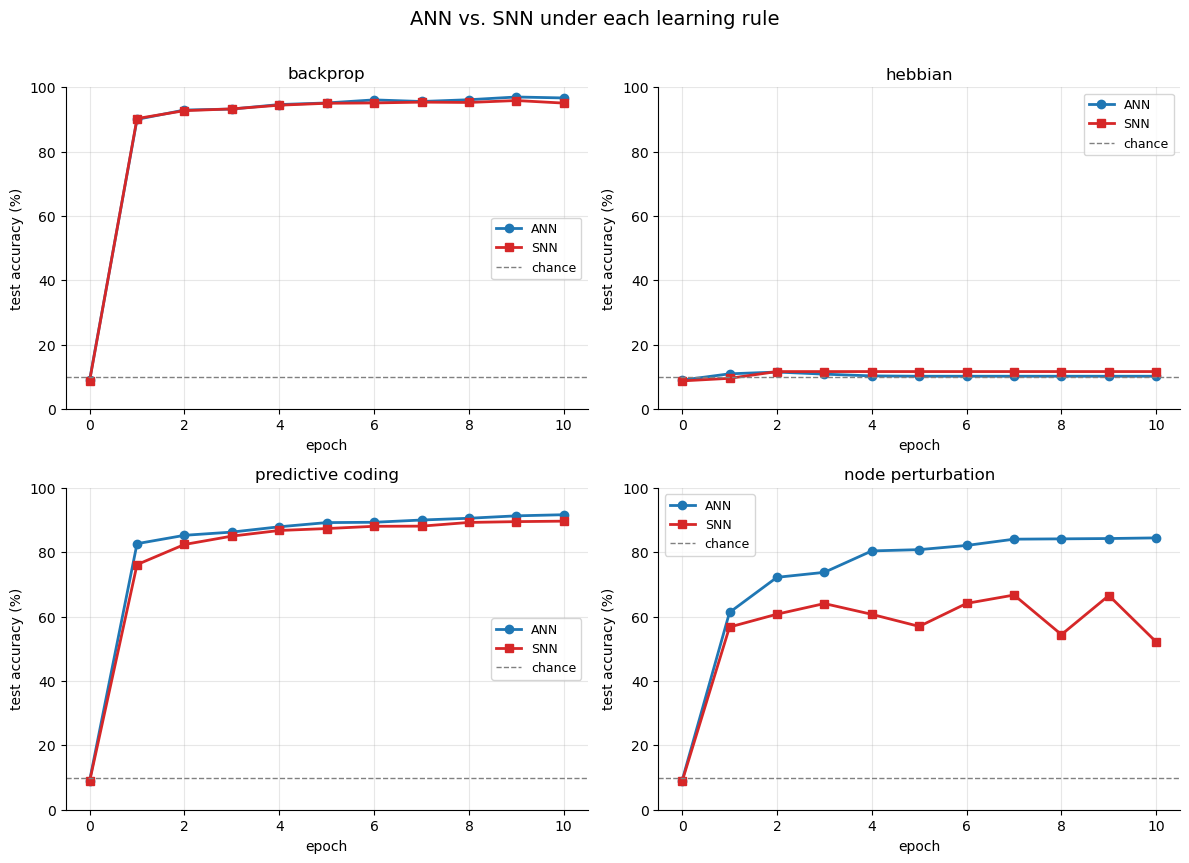

In [35]:
CHANCE = 100.0 / NUM_OUTPUTS

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
for ax, rule in zip(axes.flat, RULE_ORDER):
    ep = range(len(results["ann"][rule]["acc"]))
    ax.plot(ep, results["ann"][rule]["acc"], marker="o", lw=2, color="#1F77B4", label="ANN")
    ax.plot(ep, results["snn"][rule]["acc"], marker="s", lw=2, color="#D62728", label="SNN")
    ax.axhline(CHANCE, ls="--", color="grey", lw=1, label="chance")
    ax.set_title(rule, fontsize=12)
    ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy (%)")
    ax.set_ylim(0, 100); ax.grid(alpha=.3); ax.legend(fontsize=9)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.suptitle("ANN vs. SNN under each learning rule", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## 11. The SNN under all four rules

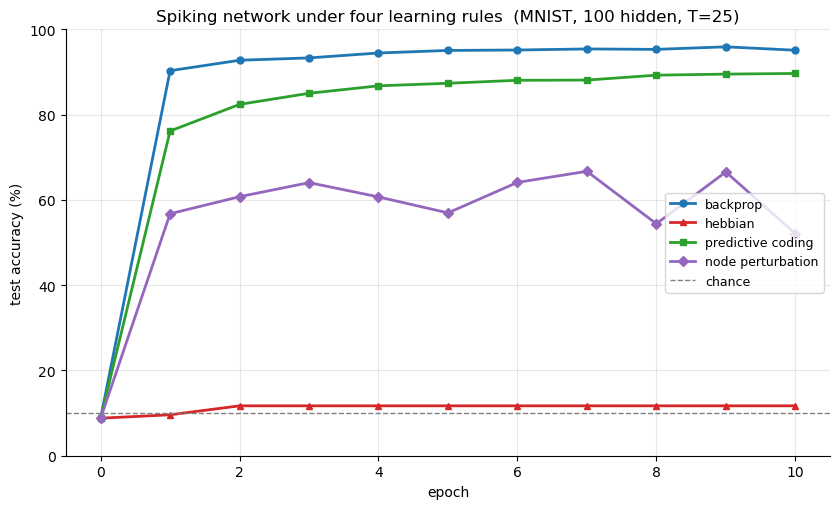

In [36]:
STYLE = {
    "backprop":          dict(color="#1F77B4", marker="o"),
    "hebbian":           dict(color="#D62728", marker="^"),
    "predictive coding": dict(color="#2CA02C", marker="s"),
    "node perturbation": dict(color="#9467BD", marker="D"),
}

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for rule in RULE_ORDER:
    ep = range(len(results["snn"][rule]["acc"]))
    ax.plot(ep, results["snn"][rule]["acc"], lw=2, ms=5, label=rule, **STYLE[rule])
ax.axhline(CHANCE, ls="--", color="grey", lw=1, label="chance")
ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy (%)")
ax.set_title(f"Spiking network under four learning rules  (MNIST, {NUM_HIDDEN} hidden, T={T_SNN})")
ax.set_ylim(0, 100); ax.grid(alpha=.3); ax.legend(fontsize=9)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 11b. The ANN under all four rules

The same view for the non-spiking network — reuses `results["ann"]`, `STYLE`, `RULE_ORDER` and `CHANCE` from above.

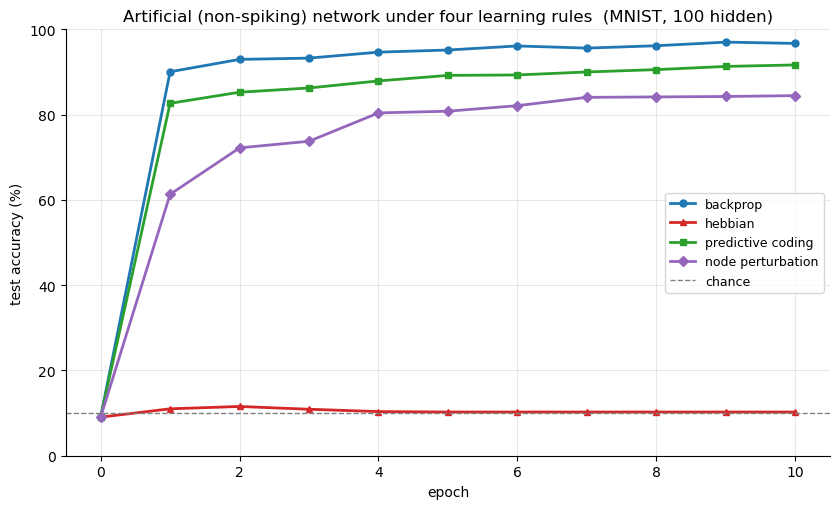

In [39]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for rule in RULE_ORDER:
    ep = range(len(results["ann"][rule]["acc"]))
    ax.plot(ep, results["ann"][rule]["acc"], lw=2, ms=5, label=rule, **STYLE[rule])
ax.axhline(CHANCE, ls="--", color="grey", lw=1, label="chance")
ax.set_xlabel("epoch"); ax.set_ylabel("test accuracy (%)")
ax.set_title(f"Artificial (non-spiking) network under four learning rules  (MNIST, {NUM_HIDDEN} hidden)")
ax.set_ylim(0, 100); ax.grid(alpha=.3); ax.legend(fontsize=9)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Final-accuracy summary

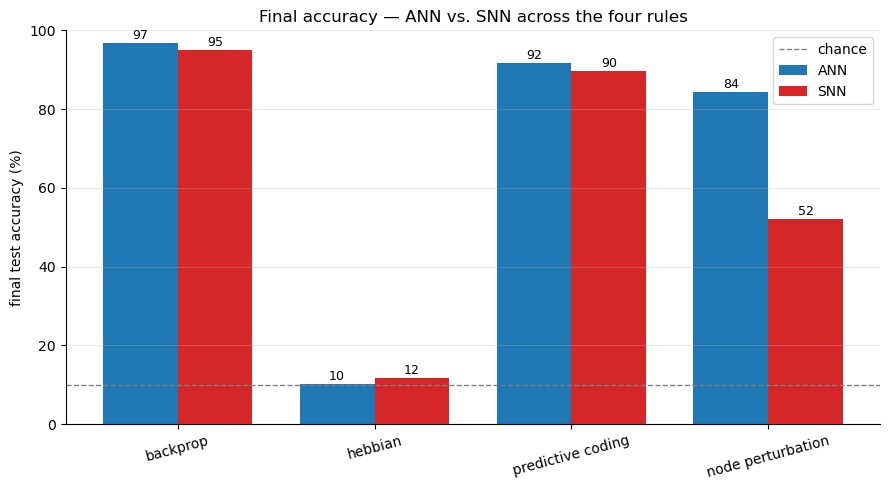

In [37]:
x = np.arange(len(RULE_ORDER)); w = 0.38
ann_final = [results["ann"][r]["acc"][-1] for r in RULE_ORDER]
snn_final = [results["snn"][r]["acc"][-1] for r in RULE_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, ann_final, w, color="#1F77B4", label="ANN")
ax.bar(x + w/2, snn_final, w, color="#D62728", label="SNN")
ax.axhline(CHANCE, ls="--", color="grey", lw=1, label="chance")
for i, (a, s) in enumerate(zip(ann_final, snn_final)):
    ax.text(i - w/2, a + 1, f"{a:.0f}", ha="center", fontsize=9)
    ax.text(i + w/2, s + 1, f"{s:.0f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(RULE_ORDER, rotation=15)
ax.set_ylabel("final test accuracy (%)"); ax.set_ylim(0, 100)
ax.set_title("Final accuracy — ANN vs. SNN across the four rules")
ax.legend(); ax.grid(alpha=.3, axis="y")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 13. Notes and caveats

**What this notebook establishes.** The same simple two-layer LIF network can be
trained by all four rules behind one interface, and each rule can be compared
directly against its ANN counterpart and against the other rules on the spiking
substrate.

**Expected ordering** (from the `Q1a_combined` findings, to check against your run):
backprop ≥ predictive coding ≥ node perturbation ≫ Hebbian. Node perturbation is
unbiased but high-variance, so it typically learns more slowly than backprop; the
Hebbian rule, having no error signal, tends to plateau well below the others (and on
all ten classes it collapses harder than on the 3-class task — the row-centring fix
from `Q1a_combined` section 10 is exposed here as `centre_rows=True`).

**Modeling choices worth stating plainly.**

* The SNN reads out by **spike count** (rate coding). All rules and the evaluation
  share this readout, which keeps the comparison fair but means the spiking network is
  being used as a rate code, not a precise-timing code.
* **Predictive coding on spikes is the experimental part.** Here the value nodes are
  seeded from a real spiking pass and the readout is through spikes, but the relaxation
  in between uses a sigmoid rate surrogate for the LIF transfer. A strict-spike PC with
  spiking error neurons is a genuine open research direction, not something this notebook
  claims to have solved.
* **Learning rates are defaults, not tuned.** Each rule exposes its own `lr` (and
  `sigma`, `gamma`, `T_relax`); expect to sweep these, especially for the SNN Hebbian
  and node-perturbation rules, before reading too much into the exact gap between curves.
* Backprop's SNN path uses BPTT with a surrogate gradient — biologically the least
  plausible but the strongest baseline.